###  Khám phá dữ liệu (EDA)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu 
df = pd.read_csv('pima-indians-diabetes.csv')

# 2. Kiểm tra sơ bộ 5 dòng đầu
print("--- kiểm tra thử 5 dòng đầu của dữ liệu ---")

print(df.head())

# 3. Kiểm tra tổng quát (Số dòng, cột, kiểu dữ liệu, ô trống)
print("\n--- Thông tin chi tiết hệ thống ---")
df.info()

# 4. Kiểm tra các chỉ số thống kê (Để soi các giá trị 0 vô lý)
print("\n--- Thống kê mô tả ---")
print(df.describe())

--- kiểm tra thử 5 dòng đầu của dữ liệu ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- Thông tin chi tiết hệ thống ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pre

### nhận xét 
##### các cột Glucose, BMI, Insulin có giá trị min = 0 là không hợp lý 

### Biểu đồ Nhiệt Correlation Heatmap

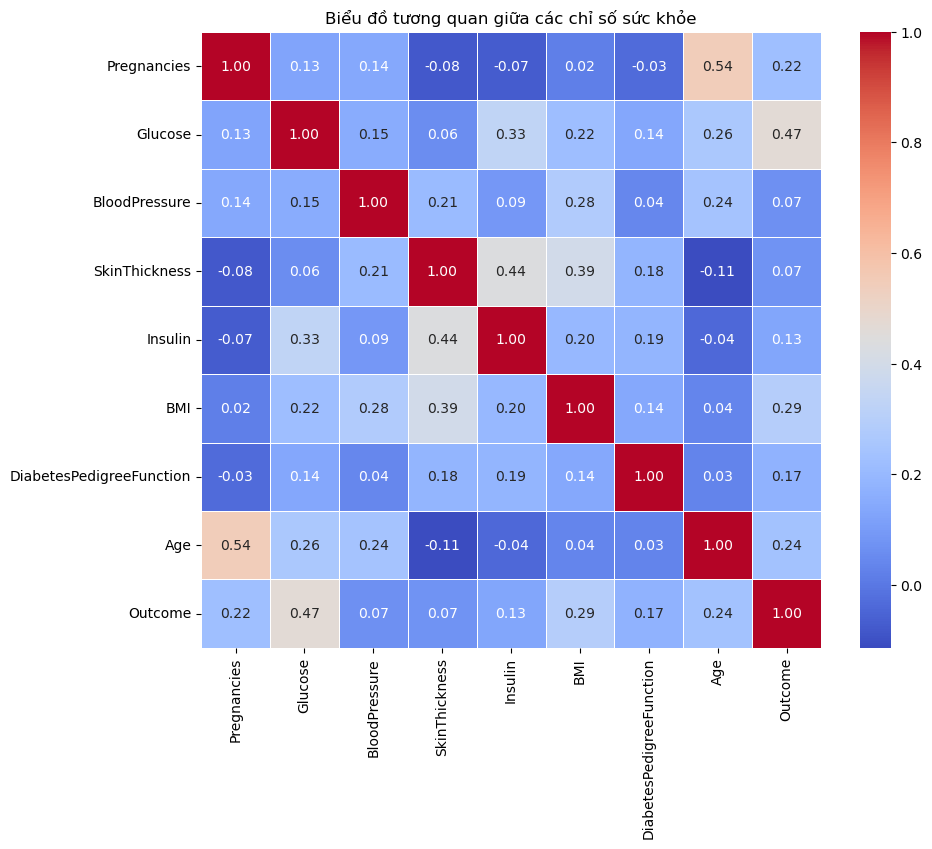

In [16]:
plt.figure(figsize=(10, 8))
# Tính toán độ tương quan giữa các cột
correlation = df.corr()
# Vẽ biểu đồ với màu sắc dễ nhìn (coolwarm)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Biểu đồ tương quan giữa các chỉ số sức khỏe')
plt.show()

### Biểu đồ phân phối lớp (Target Distribution)

C:\Users\admin\AppData\Local\Temp\ipykernel_19448\2613989022.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='magma')


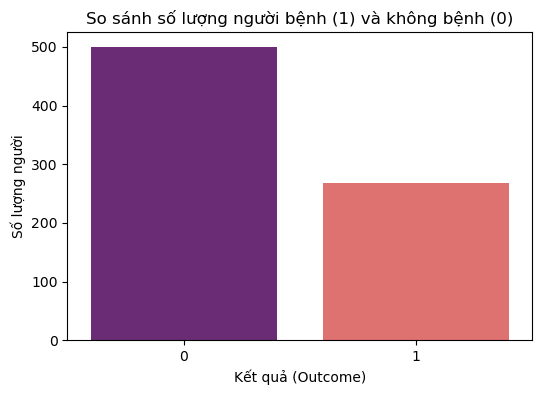

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='magma')
plt.title('So sánh số lượng người bệnh (1) và không bệnh (0)')
plt.xlabel('Kết quả (Outcome)')
plt.ylabel('Số lượng người')
plt.show()

### Biểu đồ Boxplot (Tìm Outliers - Giá trị ngoại lai)

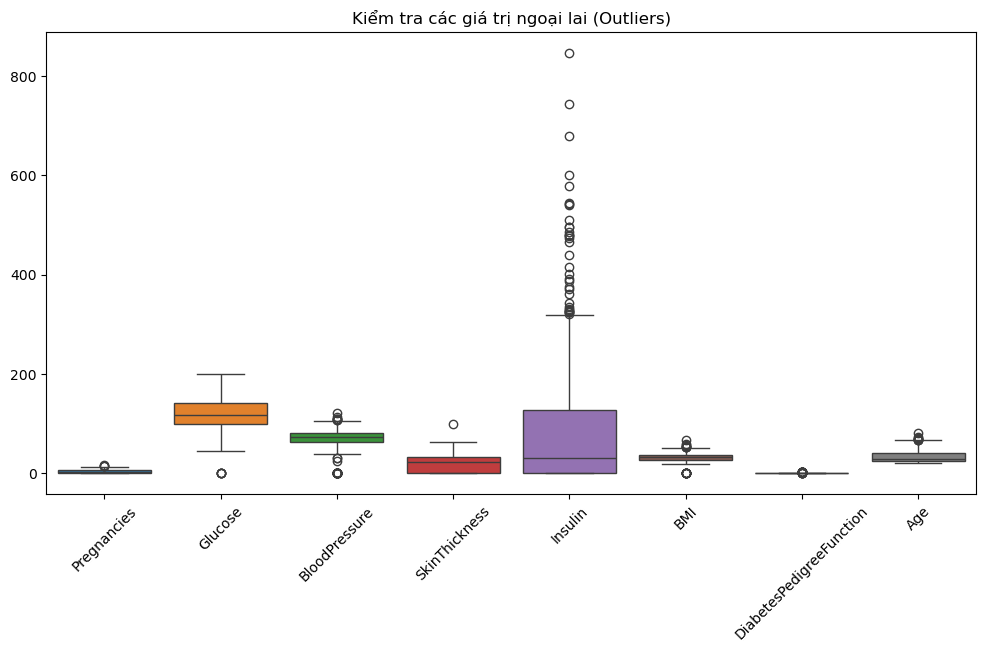

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop('Outcome', axis=1))
plt.xticks(rotation=45)
plt.title('Kiểm tra các giá trị ngoại lai (Outliers)')
plt.show()

### Nhận xét

#### Tương quan: Biến Glucose có tương quan cao nhất với Outcome (khoảng 0.47), cho thấy đây là yếu tố dự báo quan trọng nhất.

#### Cân bằng: Dữ liệu bị lệch (imbalance) khi số người không bệnh (lớp 0) chiếm đa số, gấp khoảng 2 lần số người bị bệnh (lớp 1).